# Wykorzystanie rozkładów macierzy do rozwiązywania oznaczonych układów równań

Poznane na wykładzie rozkłady (faktoryzacje) macierzy możemy wykorzystać do rozwiązywania układów równań liniowych. Dzięki wykorzystaniu specjalnych własności macierzy występujących w rozkładzie jesteśmy w stanie w łatwiejszy sposób odwrócić macierz i tym samym zminimalizować błąd.


**Zadanie 1.**

Rozważmy układ równań $Ax=b$, w którym:
* $A$ jest macierzą Hilberta o wymiarach 15x15.
* $A$ jest macierzą wartości losowych z przedziału $[0,100]$ o wymiarach 100x100,  1000x1000 i 1000000x1000000.
* $b$ jest wektorem wartości losowych, odpowiednio, o wymiarach 15x1, 100x1, 1000x1 i 1000000x1.

1. Oblicz współczynnik uwarunkowania macierzy $A$ i oceń jej uwarunkowanie.
2. Rozwiąż układ równań następującymi metodami:
    * z użyciem jawnej odwrotności $A$.
    * korzystając z rozkładu [LU](https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.lu.html) (uwaga na macierz permutacji!):
        * z wykorzystaniem odwrotności L i U.
        * z użyciem jedynie odwrotności i metody podstawiania wstecznego.
    * korzystając z rozkładu [QR](https://numpy.org/doc/stable/reference/generated/numpy.linalg.qr.html):
        * z wykorzystaniem odwrotności Q i R.
        * z użyciem jedynie odwrotności Q i metody podstawiania wstecznego.
    * za pomocą jednej z metod iteracyjnych z poprzedniego ćwiczenia.
    * za pomocą metody [`solve`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.solve.html) z pakietu NumPy.
3. Porównaj otrzymane wyniki. W tym celu oblicz normy z residuuów otrzymanych dla każdego z rozwiązań. Którą z metod cechuje najwyższa dokladność?
4. Przeprowadź porównanie wydajności ww. metod. Zmierz czas wykonania każdej metody. Aby otrzymać bardziej sensowny wynik należy powtórzyć obliczenia w pętli (np. 100 lub 1000 razy) i uśrednić wynik. Do pomiaru czasu wykonania możesz wykorzystać pakiet `time`.
Wskazówka: Do rozwiązania układu z macierzą trójkątną możesz wykorzystać funkcję [`scipy.linalg.solve_triangular`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.solve_triangular.html).

        
        


In [1]:
import numpy as np
import scipy.linalg as la
import time

def generate_hilbert(n):
    return la.hilbert(n)

def generate_random_system(size):
    A = np.random.uniform(0, 100, (size, size))
    b = np.random.uniform(0, 100, (size, 1))
    return A, b



def solve_inverse(A, b):
    return la.inv(A) @ b

def solve_lu_inverse(A, b):
    P, L, U = la.lu(A)
    
    return la.inv(U) @ la.inv(L) @ (P.T @ b)

def solve_lu_sub(A, b):
    P, L, U = la.lu(A)
   
    y = la.solve_triangular(L, P.T @ b, lower=True)
  
    x = la.solve_triangular(U, y, lower=False)
    return x

def solve_qr_inverse(A, b):
    Q, R = la.qr(A)
    
    return la.inv(R) @ (Q.T @ b)

def solve_qr_sub(A, b):
    Q, R = la.qr(A)
    
    y = Q.T @ b
    x = la.solve_triangular(R, y, lower=False)
    return x

def solve_jacobi(A, b, max_iter=100, tol=1e-10):
   
    D = np.diag(A)
    R = A - np.diagflat(D)
    x = np.zeros_like(b)
    for _ in range(max_iter):
        x_new = (b - R @ x) / D[:, None]
        if la.norm(x_new - x) < tol:
            return x_new
        x = x_new
    return x 

def solve_numpy(A, b):
    return np.linalg.solve(A, b)



def run_tests():
    
    test_cases = [
        ("Hilbert 15x15", generate_hilbert(15), np.random.uniform(0, 100, (15, 1)), 1000),
        ("Random 100x100", *generate_random_system(100), 1000),
        ("Random 1000x1000", *generate_random_system(1000), 10) 
    ]

    solvers = {
        "1. Jawna odwrotność A": solve_inverse,
        "2. LU (odwrotności)": solve_lu_inverse,
        "3. LU (podstawianie)": solve_lu_sub,
        "4. QR (odwrotności)": solve_qr_inverse,
        "5. QR (podstawianie)": solve_qr_sub,
        "6. Metoda iteracyjna (Jacobi)": solve_jacobi,
        "7. NumPy solve": solve_numpy
    }

    for name, A, b, repeats in test_cases:
        print(f"\n{'='*50}\nUkład: {name}")
        
        
        cond_A = np.linalg.cond(A)
        print(f"Współczynnik uwarunkowania cond(A): {cond_A:.2e}")
        if cond_A > 1e14:
            print(" -> UWAGA: Macierz ekstremalnie źle uwarunkowana (bliska osobliwej). Wyniki mogą być obarczone ogromnym błędem!")
        
        print(f"Liczba pomiarów dla uśrednienia czasu: {repeats}\n")
        print(f"{'Metoda':<30} | {'Błąd (Norma Residuum)':<25} | {'Średni Czas (s)'}")
        print("-" * 75)

        for solver_name, solver_func in solvers.items():
           
            try:
                
                x = solver_func(A, b)
                
                residuum = la.norm(A @ x - b)
                
               
                start_time = time.perf_counter()
                for _ in range(repeats):
                    solver_func(A, b)
                end_time = time.perf_counter()
                
                avg_time = (end_time - start_time) / repeats
                print(f"{solver_name:<30} | {residuum:<25.5e} | {avg_time:.6f}")
                
            except Exception as e:
                print(f"{solver_name:<30} | BŁĄD OBLICZEŃ              | N/A")

if __name__ == "__main__":
    np.random.seed(42) 
    run_tests()


Układ: Hilbert 15x15
Współczynnik uwarunkowania cond(A): 3.68e+17
 -> UWAGA: Macierz ekstremalnie źle uwarunkowana (bliska osobliwej). Wyniki mogą być obarczone ogromnym błędem!
Liczba pomiarów dla uśrednienia czasu: 1000

Metoda                         | Błąd (Norma Residuum)     | Średni Czas (s)
---------------------------------------------------------------------------
1. Jawna odwrotność A          | 1.34579e+02               | 0.000031
2. LU (odwrotności)            | 3.53986e+03               | 0.000077
3. LU (podstawianie)           | 3.69024e+02               | 0.000076


C:\Users\Admin\AppData\Local\Temp\ipykernel_27716\3801610341.py:16: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.567840954303546e-18.
  return la.inv(A) @ b
C:\Users\Admin\AppData\Local\Temp\ipykernel_27716\3801610341.py:21: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.9539641159662213e-18.
  return la.inv(U) @ la.inv(L) @ (P.T @ b)
C:\Users\Admin\AppData\Local\Temp\ipykernel_27716\3801610341.py:34: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.8374012925848007e-18.
  return la.inv(R) @ (Q.T @ b)


4. QR (odwrotności)            | 3.83039e+04               | 0.000091
5. QR (podstawianie)           | 1.30853e+02               | 0.000076
6. Metoda iteracyjna (Jacobi)  | 5.74868e+110              | 0.001128
7. NumPy solve                 | 3.07134e+02               | 0.000008

Układ: Random 100x100
Współczynnik uwarunkowania cond(A): 3.38e+05
Liczba pomiarów dla uśrednienia czasu: 1000

Metoda                         | Błąd (Norma Residuum)     | Średni Czas (s)
---------------------------------------------------------------------------
1. Jawna odwrotność A          | 2.48843e-09               | 0.000495
2. LU (odwrotności)            | 1.91374e-09               | 0.000653
3. LU (podstawianie)           | 7.09222e-10               | 0.000219
4. QR (odwrotności)            | 5.93836e-10               | 0.002630
5. QR (podstawianie)           | 4.50374e-10               | 0.002404


c:\Users\Admin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\linalg\_linalg.py:2767: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)


6. Metoda iteracyjna (Jacobi)  | inf                       | 0.001337
7. NumPy solve                 | 7.93488e-10               | 0.002220

Układ: Random 1000x1000
Współczynnik uwarunkowania cond(A): 7.64e+04
Liczba pomiarów dla uśrednienia czasu: 10

Metoda                         | Błąd (Norma Residuum)     | Średni Czas (s)
---------------------------------------------------------------------------
1. Jawna odwrotność A          | 1.20849e-09               | 0.086470
2. LU (odwrotności)            | 1.67665e-09               | 0.118718
3. LU (podstawianie)           | 9.46308e-10               | 0.038977
4. QR (odwrotności)            | 1.37483e-10               | 0.167505
5. QR (podstawianie)           | 1.06285e-10               | 0.133775
6. Metoda iteracyjna (Jacobi)  | BŁĄD OBLICZEŃ              | N/A


C:\Users\Admin\AppData\Local\Temp\ipykernel_27716\3801610341.py:49: RuntimeWarning: overflow encountered in matmul
  x_new = (b - R @ x) / D[:, None]


7. NumPy solve                 | 8.48191e-10               | 0.032061


# Interpolacja

**Zadanie 2.**

Przeprowadź interpolacje poniższych funkcji $f(x)$ za pomocą wielomianów interpolacyjnych Lagrange'a ([`scipy.interpolate.lagrange`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.lagrange.html)). Stwórz wykresy funkcji interpolacyjnych i zaznacz na nich punkty, w ktorych dokonano oceny wartości funkcji.

Pierwsza funkcja:

* $f(0) = 1$,
* $f(0.25) = 1.64872$,
* $f(0.5) = 2.71828$,
* $f(0.75) = 4.48169.$

Oblicz $f(0.43)$.

Druga funkcja:

* $f_2(0.1) = 0.62049958$,
* $f_2(0.2) = -0.28398668$,
* $f_2(0.3) = 0.00660095$,
* $f_2(0.4) = 0.24842440$. 

Oblicz $f_2(0.25)$.

--- Pierwsza funkcja ---
Wielomian Lagrange'a:
       3         2
2.912 x + 1.183 x + 2.117 x + 1

f(0.43) = 2.36060

--- Druga funkcja ---
Wielomian Lagrange'a:
        3         2
-207.3 x + 184.1 x - 49.77 x + 3.964

f2(0.25) = -0.21034



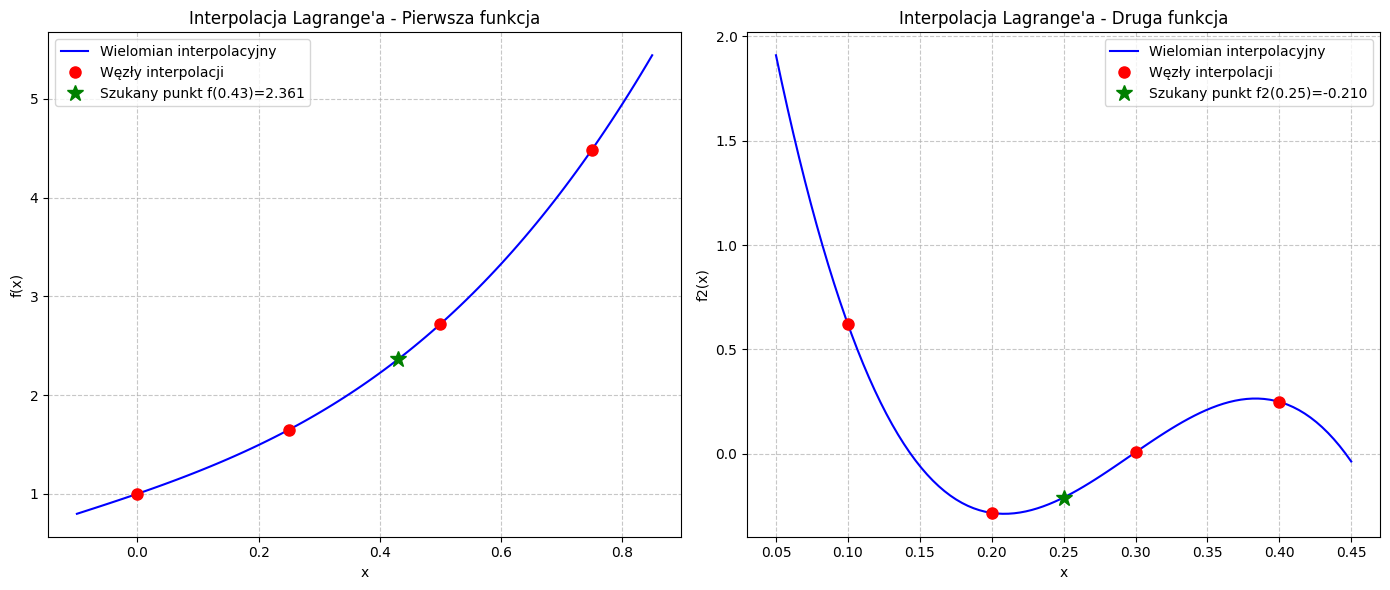

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import lagrange


x1 = np.array([0.0, 0.25, 0.5, 0.75])
y1 = np.array([1.0, 1.64872, 2.71828, 4.48169])
target_x1 = 0.43


poly1 = lagrange(x1, y1)


target_y1 = poly1(target_x1)
print(f"--- Pierwsza funkcja ---")
print(f"Wielomian Lagrange'a:\n{poly1}\n")
print(f"f(0.43) = {target_y1:.5f}\n")


x2 = np.array([0.1, 0.2, 0.3, 0.4])
y2 = np.array([0.62049958, -0.28398668, 0.00660095, 0.24842440])
target_x2 = 0.25


poly2 = lagrange(x2, y2)


target_y2 = poly2(target_x2)
print(f"--- Druga funkcja ---")
print(f"Wielomian Lagrange'a:\n{poly2}\n")
print(f"f2(0.25) = {target_y2:.5f}\n")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))


x1_dense = np.linspace(-0.1, 0.85, 100)
x2_dense = np.linspace(0.05, 0.45, 100)


ax1.plot(x1_dense, poly1(x1_dense), 'b-', label='Wielomian interpolacyjny')
ax1.plot(x1, y1, 'ro', markersize=8, label='Węzły interpolacji')
ax1.plot(target_x1, target_y1, 'g*', markersize=12, label=f'Szukany punkt f(0.43)={target_y1:.3f}')
ax1.set_title('Interpolacja Lagrange\'a - Pierwsza funkcja')
ax1.set_xlabel('x')
ax1.set_ylabel('f(x)')
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()


ax2.plot(x2_dense, poly2(x2_dense), 'b-', label='Wielomian interpolacyjny')
ax2.plot(x2, y2, 'ro', markersize=8, label='Węzły interpolacji')
ax2.plot(target_x2, target_y2, 'g*', markersize=12, label=f'Szukany punkt f2(0.25)={target_y2:.3f}')
ax2.set_title('Interpolacja Lagrange\'a - Druga funkcja')
ax2.set_xlabel('x')
ax2.set_ylabel('f2(x)')
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

plt.tight_layout()
plt.show()

***Zadanie 3.***

Rozważmy funkcję $f(x)=\frac{1}{25x^2+1}$. 

Przeprowadź interpolacje funkcji $f$ w przedziale $[-2,2]$ wielomianem Lagrange'a oraz funkcjami sklejanymi 3 stopnia w:
- 21 równoodległych węzłach,
- 21 węzłach [Czebyszewa](https://pl.wikipedia.org/wiki/Węzły_Czebyszewa).

**Wskazówka** Interpolację funkcjami sklejanymi możesz przeprowadzić za pomocą funkcji [`interp1d`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.interp1d.html#scipy.interpolate.interp1d).

Umieść wielomian interpolacyjny, oryginalną funkcję $f$ oraz węzly interpolacyjne na wspólnym wykresie (jeden wykres dla metody Lagrange'a oraz jeden dla funkcji sklejanych). Porównaj otrzymane rezultaty. Przeprowadź te same działania dla przedziału $x\in[-5,5]$. Jakie problemy możesz zauważyć na otrzymanych wykresach?

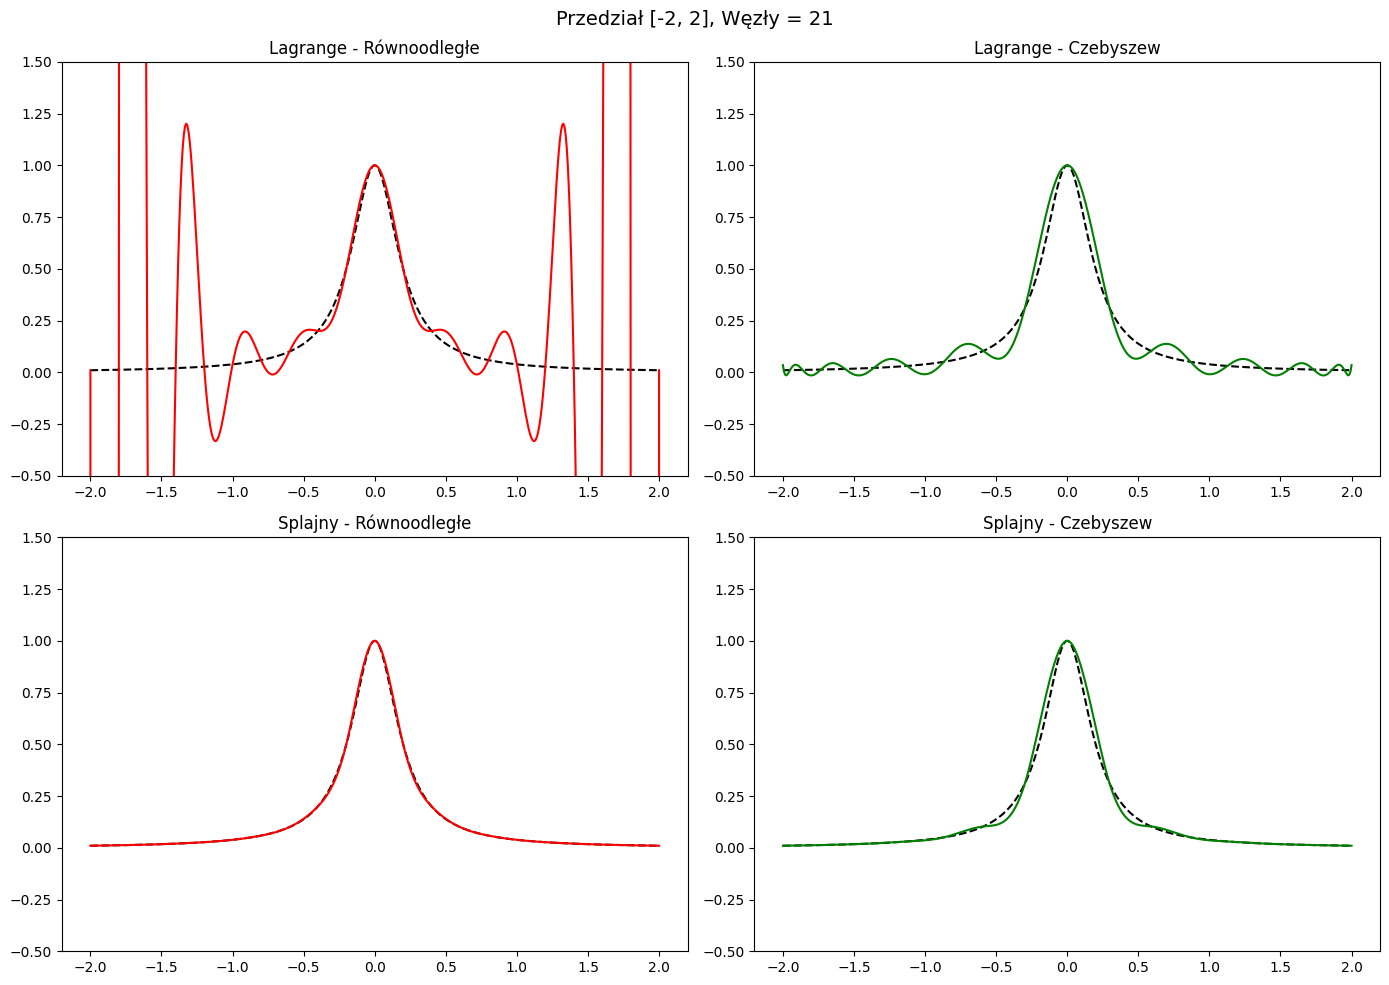

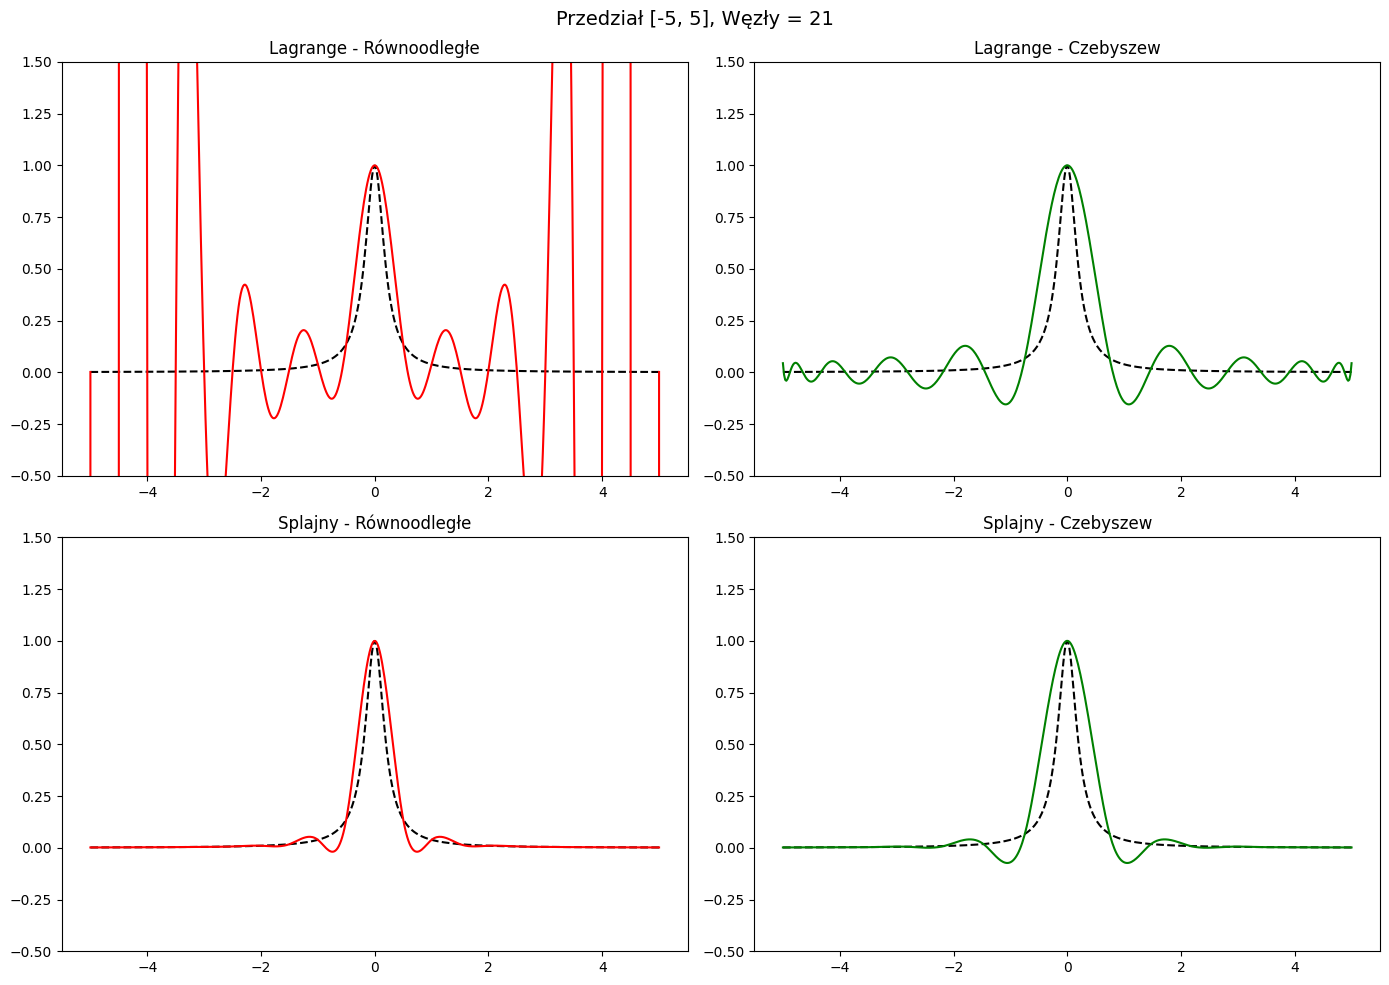

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import lagrange, interp1d
import warnings


warnings.filterwarnings("ignore")

def f(x):
    return 1 / (25 * x**2 + 1)

def chebyshev_nodes(a, b, n):
    k = np.arange(n)
    t = np.cos((2 * k + 1) * np.pi / (2 * n))
    return 0.5 * (a + b) + 0.5 * (b - a) * t

def run_interpolation(a, b, n=21):
    x_eq = np.linspace(a, b, n)
    x_cheb = np.sort(chebyshev_nodes(a, b, n)) 
    
    y_eq = f(x_eq)
    y_cheb = f(x_cheb)
    
    x_dense = np.linspace(a, b, 500)
    y_true = f(x_dense)
    
    poly_lagrange_eq = lagrange(x_eq, y_eq)
    poly_lagrange_cheb = lagrange(x_cheb, y_cheb)
    
    
    spline_eq = interp1d(x_eq, y_eq, kind='cubic', fill_value="extrapolate")
    spline_cheb = interp1d(x_cheb, y_cheb, kind='cubic', fill_value="extrapolate")
    
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'Przedział [{a}, {b}], Węzły = {n}', fontsize=14)
    
    axs[0, 0].plot(x_dense, y_true, 'k--', label='Oryginał')
    axs[0, 0].plot(x_dense, poly_lagrange_eq(x_dense), 'r-', label='Lagrange')
    axs[0, 0].set_title('Lagrange - Równoodległe')
    axs[0, 0].set_ylim(-0.5, 1.5)
    
    axs[0, 1].plot(x_dense, y_true, 'k--', label='Oryginał')
    axs[0, 1].plot(x_dense, poly_lagrange_cheb(x_dense), 'g-', label='Lagrange')
    axs[0, 1].set_title('Lagrange - Czebyszew')
    axs[0, 1].set_ylim(-0.5, 1.5)
    
    axs[1, 0].plot(x_dense, y_true, 'k--', label='Oryginał')
    axs[1, 0].plot(x_dense, spline_eq(x_dense), 'r-', label='Spline 3')
    axs[1, 0].set_title('Splajny - Równoodległe')
    axs[1, 0].set_ylim(-0.5, 1.5)
    
    axs[1, 1].plot(x_dense, y_true, 'k--', label='Oryginał')
    axs[1, 1].plot(x_dense, spline_cheb(x_dense), 'g-', label='Spline 3')
    axs[1, 1].set_title('Splajny - Czebyszew')
    axs[1, 1].set_ylim(-0.5, 1.5)
    
    plt.tight_layout()
    plt.show()

run_interpolation(-2, 2, 21)
run_interpolation(-5, 5, 21)

1. Analiza i Wnioski

Przedział $[-2, 2]$ (Równoodległe węzły): Wielomian Lagrange'a zaczyna wykazywać lekkie oscylacje (falowanie) na krańcach przedziału (w okolicach $-2$ oraz $2$). Funkcja sklejana idealnie pokrywa się z funkcją oryginalną.Przedział $[-5, 5]$ (Równoodległe węzły) – Efekt Rungego: Tutaj problem staje się katastrofalny. Wielomian Lagrange'a 20. stopnia (dla 21 węzłów) na krańcach przedziału "wystrzela" w kosmos, osiągając ogromne wartości (oscylacje rzędu kilkudziesięciu/kilkuset), mimo że oryginalna funkcja dąży tam do zera. To jest właśnie efekt Rungego.Węzły Czebyszewa: Zastosowanie węzłów Czebyszewa całkowicie eliminuje ten problem dla wielomianu Lagrange'a! Ponieważ węzły te zagęszczają się blisko krańców przedziału, maksymalny błąd interpolacji zostaje zminimalizowany, a wielomian idealnie przygasa na końcach, doskonale przybliżając funkcję Rungego.Funkcje sklejane (Splajny 3. stopnia): Radzą sobie doskonale w każdym przypadku (zarówno dla węzłów równoodległych, jak i Czebyszewa, w obu przedziałach). Ponieważ interpolacja sklejana polega na łączeniu lokalnych wielomianów niskiego (3.) stopnia, nie cierpi ona na efekt Rungego, który jest domeną globalnych wielomianów wysokiego stopnia.


***Zadanie 4.***

Kierowca jadący z miasta A do miasta B, zauważywszy na drodze fotoradar, zaczął gwałtownie hamować. Przebieg jego położenia, zarejestrowany przez nawigację, pokazano w poniższej tabeli. Wiedząc, że radar znajduje się w punkcie o współrzędnej 79.6 m, oszacuj kiedy kierowca minął fotoradar (w tym celu skorzystaj z jednej z metod z laboratorium 3) oraz z jaką prędkością wtedy jechał (wykorzystaj relację drogi i prędkości znaną z fizyki). 

|czas \[s\]|położenie \[m\]|
|--|--|
|0.0|0.0|
|1.0|42.7|
|2.0|73.2|
|3.0|92.5|

**Zadanie dla zainteresowanych programowaniem funkcyjnym w Pythonie**

Stwórz funkcję znajdującą wielomian interpolacyjny metodą Lagrange'a. Funkcja powinna przyjmować dwie listy:
* listę argumentów ($x$-ów)
* listę wartości ($y$-ów).  


Po wykonaniu obliczeń funkcja powinna zwracać wielomian w postaci obiektu typu **funkcja** (a nie `numpy.Polynomial`).

**Wskazówka** Wykorzystaj wyrażenia *lambda*. Dla ułatwienia możesz się też posłużyć pakietami `operator` i `functools`.
